# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [29]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [30]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

shape of training data:  (50000, 32, 32, 3)
number of rows in training data:  50000
training data pixel heightxwidth: 32x32
training data colors:  3
training data labels number of rows: 50000 and columns: 1
shape of test data:  (10000, 32, 32, 3)
number of rows in test data:  10000
test data pixel heightxwidth: 32x32
test data colors:  3
test data labels number of rows: 10000 and columns: 1


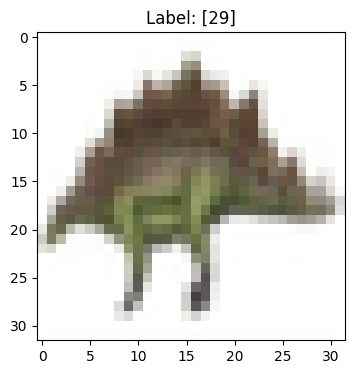

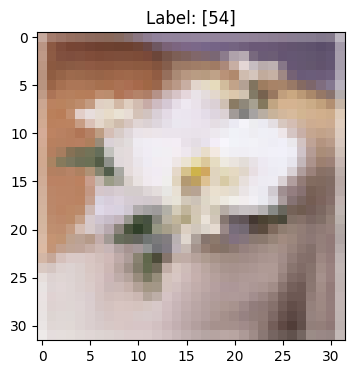

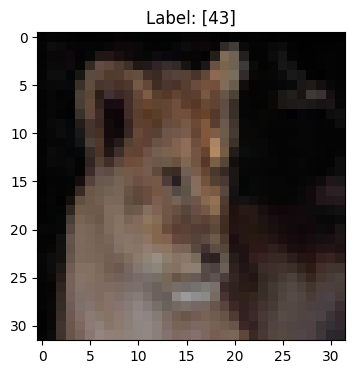

In [54]:
# Your Code Here

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

print("shape of training data: ", x_train.shape)
print("number of rows in training data: ", x_train.shape[0])
print(f"training data pixel heightxwidth: {x_train.shape[1]}x{x_train.shape[2]}")
print("training data colors: ", x_train.shape[3])
print(f"training data labels number of rows: {y_train.shape[0]} and columns: {y_train.shape[1]}")
print("shape of test data: ", x_test.shape)
print("number of rows in test data: ", x_test.shape[0])
print(f"test data pixel heightxwidth: {x_train.shape[1]}x{x_train.shape[2]}")
print("test data colors: ", x_test.shape[3])
print(f"test data labels number of rows: {y_test.shape[0]} and columns: {y_test.shape[1]}")

a_0=1
a_1=1000
a_2=20245

plt.figure(figsize=(4, 4))
plt.imshow(x_train[a_0])  # Display the image
plt.title(f"Label: {y_train[a_0]}")  # Display the label (class)

plt.figure(figsize=(4, 4))
plt.imshow(x_train[a_1])  # Display the image
plt.title(f"Label: {y_train[a_1]}")  # Display the label (class)

plt.figure(figsize=(4, 4))
plt.imshow(x_train[a_2])  # Display the image
plt.title(f"Label: {y_train[a_2]}")  # Display the label (class)
plt.show()

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [32]:
# Your Code Here
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_one_hot = to_categorical(y_train, num_classes=100)
y_test_one_hot = to_categorical(y_test, num_classes=100)

x_train_new, x_validate, y_train_new, y_validate = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [35]:
# Your Code Here
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Define the CNN model architecture
model = Sequential()

# First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the 3D output to 1D
model.add(Flatten())

# Fully Connected Dense Layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Dense Layer
model.add(Dense(100, activation='softmax'))

# Print the model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,168,356 (8.27 MB)

 Trainable params: 2,168,356 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [44]:
# Your Code Here

from tensorflow.keras.metrics import AUC
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy', AUC()])

"""
Loss function: categorical crossentropy
The loss function chosen is categorical crossentropy because it is commonly used
for multi-class classification problems like this, where there are many
mutually exclusive classes. It is common because it penalizes the model
more strongly if it is confident but wrong, therefore helping to make more
accurate predictions.

Optimizer: Adam
The optimizer chosen is Adam because it is a popular optimizer. It automates the
learning rates for each parameters, making it good in cases like this where the
data has lots of variation.
"""

' \nLoss function: categorical crossentropy\nThe loss function chosen is categorical crossentropy because it is commonly used\nfor multi-class classification problems like this, where there are many\nmutually exclusive classes. It is common because it penalizes the model\nmore strongly if it is confident but wrong, therefore helping to make more \naccurate predictions.\n\nOptimizer: Adam\nThe optimizer chosen is Adam because it is a popular optimizer. It automates the\nlearning rates for each parameters, making it good in cases like this where the\ndata has lots of variation.\n'

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [45]:
# Your Code Here

history = model.fit(
    x_train_new, y_train_new,
    epochs=10,
    batch_size=32,
    validation_data=(x_validate, y_validate),
    verbose=1
)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5549 - auc: 0.9717 - loss: 1.5653 - val_accuracy: 0.3864 - val_auc: 0.9054 - val_loss: 2.5914
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5927 - auc: 0.9758 - loss: 1.4334 - val_accuracy: 0.3829 - val_auc: 0.9055 - val_loss: 2.6121
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6144 - auc: 0.9788 - loss: 1.3444 - val_accuracy: 0.3800 - val_auc: 0.8979 - val_loss: 2.7056
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6337 - auc: 0.9816 - loss: 1.2389 - val_accuracy: 0.3794 - val_auc: 0.8941 - val_loss: 2.7482
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6545 - auc: 0.9831 - loss: 1.1684 - val_accuracy: 0.3751 - val_auc: 0.8933 - val_loss: 2.7827
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6741 - auc: 0.9854 - loss: 1.0853 - val_accuracy: 0.3688 - val_auc: 0.8825 - val_loss: 2.9462
Epoch 7/10
1250/1250 ━━━

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [47]:
# Your Code Here

test_loss, test_accuracy, test_auc = model.evaluate(x_test, y_test_one_hot, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

"""
Accuracy: 38.73%
Other metric: AUC-ROC
Reason for selection: AUC-ROC evaluates how well the model distinguishes
between classes across all possible thresholds and shows how well the model
classifies both majority and minority classes.
Value of metric: 0.8674
Interpretation of metric value: Since AUC ranges between 0 and 1, the value of
0.8674 shows that the model is good at distinguishing between the classes
"""


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3850 - auc: 0.8677 - loss: 3.1867
Test Accuracy: 37.83%
Test AUC: 0.8674


'\nAccuracy: 38.73%\nOther metric: AUC-ROC\nReason for selection: AUC-ROC evaluates how well the model distinguishes\nbetween classes across all possible thresholds and shows how well the model\nclassifies both majority and minority classes.\nValue of metric: 0.8674\nInterpretation of metric value: Since AUC ranges between 0 and 1, the value of\n0.8674 shows that the model is good at distinguishing between the classes\n'

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

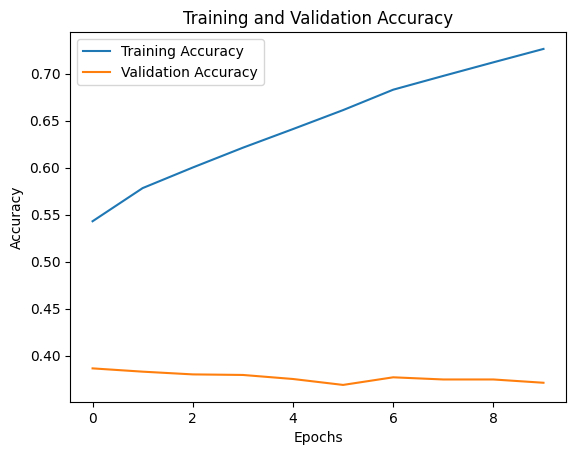

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


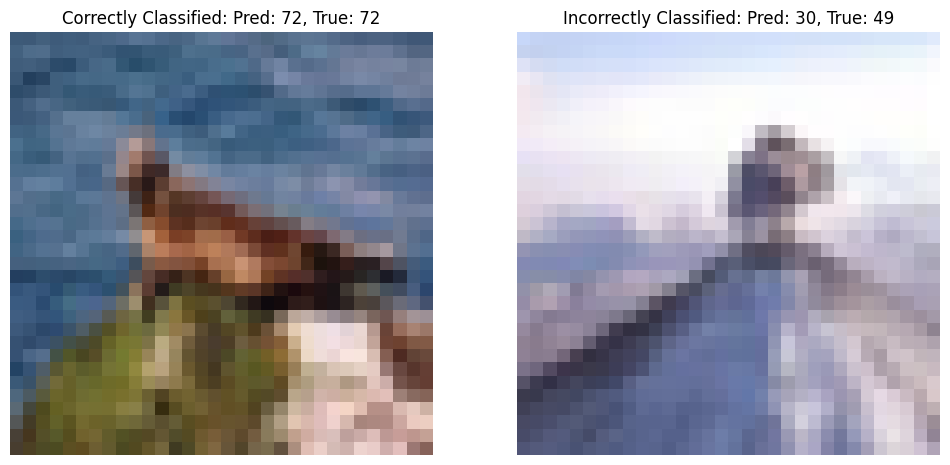

Predicted probabilities for the correctly classified image: [3.42827491e-08 1.64671183e-05 3.09908974e-05 2.57091215e-05
 1.01151764e-01 9.23767493e-06 2.01231000e-04 6.78920624e-05
 5.42597518e-05 6.02144752e-08 6.14995088e-06 4.90911771e-05
 4.02746536e-03 7.13419111e-04 1.72623969e-03 1.08193832e-04
 5.91995922e-06 1.75400255e-05 7.62620039e-05 3.01372493e-04
 5.76597188e-08 1.42038445e-07 1.66287100e-06 5.44147383e-07
 5.07926894e-03 4.53129331e-07 7.16848439e-03 2.36296967e-01
 1.21666579e-08 6.42454834e-04 2.47948188e-02 7.13137779e-05
 5.86195347e-06 8.79183972e-06 2.55892781e-04 9.74389059e-06
 3.03949861e-07 8.79402040e-04 1.62491542e-05 1.93886517e-05
 2.56069761e-04 1.68167276e-03 3.00624401e-06 5.51586481e-07
 2.32997374e-03 1.00699246e-01 1.07977685e-04 1.84194550e-06
 1.70553045e-04 2.28127810e-05 9.69167741e-06 1.64153357e-06
 5.80803462e-05 2.03503035e-12 1.48770778e-06 2.12298468e-01
 7.93061045e-04 3.20422060e-07 6.06467474e-05 8.32665339e-03
 5.38013364e-06 1.4521636

In [49]:
# Your Code Here

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Make predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)
correct_idx = np.where(y_pred_classes == y_true_classes)[0][0]
incorrect_idx = np.where(y_pred_classes != y_true_classes)[0][0]
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_idx])
plt.title(f"Correctly Classified: Pred: {y_pred_classes[correct_idx]}, True: {y_true_classes[correct_idx]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_idx])
plt.title(f"Incorrectly Classified: Pred: {y_pred_classes[incorrect_idx]}, True: {y_true_classes[incorrect_idx]}")
plt.axis('off')

plt.show()

# Print the predicted probabilities for both images
print(f"Predicted probabilities for the correctly classified image: {y_pred[correct_idx]}")
print(f"Predicted probabilities for the incorrectly classified image: {y_pred[incorrect_idx]}")




## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [60]:
# Your Code Here
from keras.layers import BatchNormalization, Activation


# Define the CNN model architecture
model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(100, activation='softmax'))

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,168,484 (8.27 MB)

 Trainable params: 2,168,420 (8.27 MB)

 Non-trainable params: 64 (256.00 B)

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0740 - auc_1: 0.7157 - loss: 4.1762 - val_accuracy: 0.2009 - val_auc_1: 0.8679 - val_loss: 3.3518
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2170 - auc_1: 0.8708 - loss: 3.2655 - val_accuracy: 0.2635 - val_auc_1: 0.8971 - val_loss: 3.0316
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2826 - auc_1: 0.9046 - loss: 2.8768 - val_accuracy: 0.3075 - val_auc_1: 0.9075 - val_loss: 2.7822
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3385 - auc_1: 0.9240 - loss: 2.5935 - val_accuracy: 0.3124 - val_auc_1: 0.9072 - val_loss: 2.7796
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3890 - auc_1: 0.9368 - loss: 2.3478 - val_accuracy: 0.3479 - val_auc_1: 0.9233 - val_loss: 2.5855
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4318 - auc_1: 0.9472 - loss: 2.1473 - val_accuracy: 0.2382 - val_auc_1: 0.8488 - val_loss: 3.3765
Ep

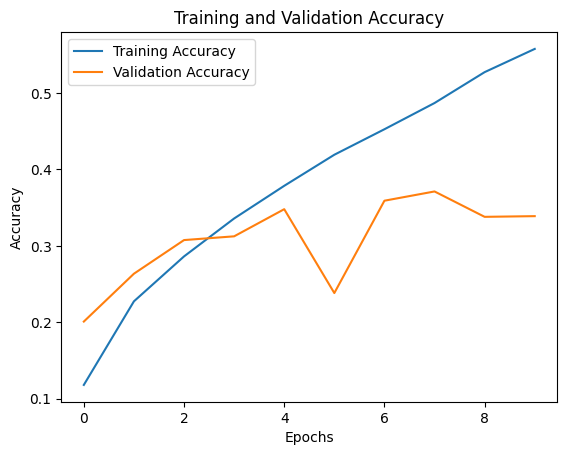

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


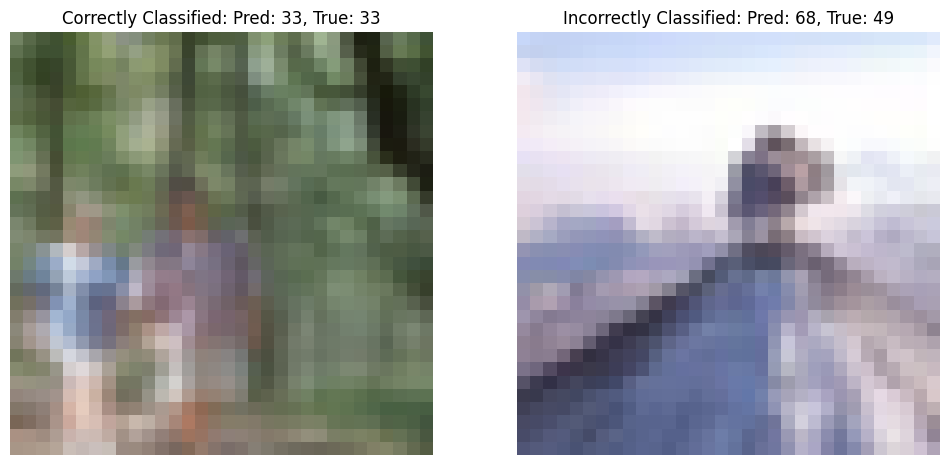

Predicted probabilities for the correctly classified image: [1.84460123e-06 1.02825183e-02 1.78581846e-04 1.83089240e-03
 6.38572127e-03 6.09353810e-05 6.53702300e-03 1.09896821e-03
 4.13973536e-03 1.68155035e-04 2.25976488e-04 9.37527278e-04
 9.58551711e-04 6.40113140e-05 1.85008384e-02 2.47307937e-04
 1.30725302e-05 4.46971353e-06 1.89217459e-02 3.98223201e-05
 1.20392351e-05 5.33279126e-05 2.85224436e-04 2.14134372e-04
 1.61318330e-05 2.57335691e-04 5.05451579e-04 2.07264666e-02
 1.09485285e-04 6.08591642e-03 4.51331289e-05 1.46912341e-03
 4.30770498e-03 2.51472622e-01 1.51898982e-02 6.00083498e-04
 2.96246668e-04 2.75830360e-04 8.91031418e-03 2.65265652e-03
 6.74370722e-06 1.49091517e-04 1.00768775e-01 7.04328704e-04
 2.30740476e-02 1.26690511e-03 1.42606423e-05 3.05631501e-03
 1.46833961e-04 4.17288975e-05 2.32554860e-02 6.80604344e-03
 4.40852637e-05 1.00348110e-07 4.82377480e-04 3.98003031e-03
 2.90251616e-03 1.01808582e-04 5.31942205e-05 3.72096128e-03
 2.03463424e-06 2.4041080

In [62]:
# Your Code Here
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy', AUC()])

history2 = model.fit(
    x_train_new, y_train_new,
    epochs=10,
    batch_size=32,
    validation_data=(x_validate, y_validate),
    verbose=1
)
test_loss, test_accuracy, test_auc = model.evaluate(x_test, y_test_one_hot, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Make predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)
correct_idx = np.where(y_pred_classes == y_true_classes)[0][0]
incorrect_idx = np.where(y_pred_classes != y_true_classes)[0][0]
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(x_test[correct_idx])
plt.title(f"Correctly Classified: Pred: {y_pred_classes[correct_idx]}, True: {y_true_classes[correct_idx]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_test[incorrect_idx])
plt.title(f"Incorrectly Classified: Pred: {y_pred_classes[incorrect_idx]}, True: {y_true_classes[incorrect_idx]}")
plt.axis('off')

plt.show()

# Print the predicted probabilities for both images
print(f"Predicted probabilities for the correctly classified image: {y_pred[correct_idx]}")
print(f"Predicted probabilities for the incorrectly classified image: {y_pred[incorrect_idx]}")




### Task 4c: Discussion of the results

- Briefly discuss the results.
- Did the model's performance improve?
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

In [ ]:
"""
There didn't seem to be much difference between the two models.
The accuracy went down from 37 to 34%.
AUC went up from 0.8674 to 0.8947.
I'm not sure why this would be. Perhaps the layer is in the wrong position
or the relevant hyperparameters are not tuned correctly.
There is definitely room for improvement. The accuracy is quite low.
I might try Data Augmentation in the future.
It seems to be popular and works by creating new data through transformations
of the original data. Using more data to train helps the model to generalize better
"""

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.